# Vergence — convergence and divergence tests

Verifies the binocular vergence controller (vergence.py) implemented as a
disparity-driven position integrator with Smith predictor — structurally
identical to smooth pursuit but driven by binocular position disparity
rather than target velocity.

**Signal flow:**
```
e_disp = pos_delayed_L − pos_delayed_R   (binocular disparity, deg)
    ↓ Smith predictor: e_pred = (e_disp − x_verg) / (1 + K_phasic_verg)
    ↓ vergence integrator: dx_verg = −x_verg/τ + K_verg·e_pred
    ↓ u_verg: vergence position command
    ↓ split: motor_cmd_L = version + ½·u_verg
             motor_cmd_R = version − ½·u_verg
```

**Tests:**
1. **Pure vergence step** — target jumps from 2 m → 0.15 m → 2 m; head stationary
2. **Version + vergence** — target jumps laterally AND in depth simultaneously

In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from oculomotor.sim.simulator import (
    PARAMS_DEFAULT, with_brain, simulate,
    _IDX_NI, _IDX_VERG,
    _IDX_VIS_L, _IDX_VIS_R,
)
from oculomotor.models.sensory_models.sensory_model import C_pos, C_target_visible
from oculomotor import __version__

print(f'oculomotor {__version__}')
THETA = PARAMS_DEFAULT
IPD   = THETA.sensory.ipd   # 0.064 m
print(f'IPD={IPD*1000:.0f} mm  K_verg={THETA.brain.K_verg}  '
      f'K_phasic_verg={THETA.brain.K_phasic_verg}  tau_verg={THETA.brain.tau_verg} s')

%matplotlib widget
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 9


def target_verg_demand(z_m):
    """Expected vergence angle for a midline target at depth z_m (m)."""
    return np.degrees(2 * np.arctan(IPD / 2 / np.asarray(z_m)))


def ax_fmt(ax, ylabel='', xlabel=''):
    ax.axhline(0, color='gray', lw=0.4)
    ax.grid(True, alpha=0.2)
    if ylabel: ax.set_ylabel(ylabel, fontsize=8)
    if xlabel: ax.set_xlabel(xlabel, fontsize=8)
    ax.tick_params(labelsize=7)

---
## Test 1 — Pure vergence step

Head stationary, target on the midline. Two depth steps:
- t = 0–2 s: target at 2 m (vergence demand ≈ 1.8°)
- t = 2–7 s: target jumps to 0.15 m (vergence demand ≈ 24°) → convergence
- t = 7–12 s: target jumps back to 2 m → divergence

SG should NOT fire (version error ≈ 0 for a midline target).

In [2]:
DT   = 0.001
t1   = jnp.arange(0.0, 12.0, DT)
T1   = len(t1)

# Target depth: far → near → far (midline, x=y=0)
z1 = jnp.where(t1 < 2.0, 2.0, jnp.where(t1 < 7.0, 0.15, 2.0))
pt1 = jnp.stack([jnp.zeros(T1), jnp.zeros(T1), z1], axis=1)   # (T, 3)

print('Simulating Test 1 (pure vergence step)...')
st1 = simulate(
    THETA, t1,
    p_target_array       = pt1,
    scene_present_array  = jnp.ones(T1),
    target_present_array = jnp.ones(T1),
    max_steps            = T1 + 500,
    return_states        = True,
)
print('Done.')

# Extract signals
t1_np   = np.array(t1)
z1_np   = np.array(z1)
ep_L1   = np.array(st1.plant[:, 0])           # L eye yaw (deg)
ep_R1   = np.array(st1.plant[:, 3])           # R eye yaw (deg)
version1 = 0.5 * (ep_L1 + ep_R1)              # conjugate (version)
vergence1 = ep_L1 - ep_R1                     # actual vergence from plant state
x_verg1  = np.array(st1.brain[:, _IDX_VERG])  # vergence integrator state
demand1  = target_verg_demand(z1_np)           # geometric vergence demand

# Disparity signal driving vergence (from visual cascade)
x_vis_L1 = np.array(st1.sensory[:, _IDX_VIS_L])
x_vis_R1 = np.array(st1.sensory[:, _IDX_VIS_R])
pos_L1   = x_vis_L1 @ np.array(C_pos).T       # (T, 3) delayed pos error L eye
pos_R1   = x_vis_R1 @ np.array(C_pos).T       # (T, 3) delayed pos error R eye
disp1    = pos_L1[:, 0] - pos_R1[:, 0]        # yaw disparity (deg)

print(f'\nFar  target (2 m):   demand={target_verg_demand(2.0):.2f}°  '
      f'vergence final={vergence1[1900]:.2f}°')
print(f'Near target (0.15m): demand={target_verg_demand(0.15):.2f}°  '
      f'vergence final={vergence1[6900]:.2f}°')
print(f'Far  target again:   demand={target_verg_demand(2.0):.2f}°  '
      f'vergence final={vergence1[-1]:.2f}°')
print(f'Version (should be ~0): max={np.max(np.abs(version1)):.2f}°')

Simulating Test 1 (pure vergence step)...
Done.

Far  target (2 m):   demand=1.83°  vergence final=1.75°
Near target (0.15m): demand=24.09°  vergence final=23.62°
Far  target again:   demand=1.83°  vergence final=1.80°
Version (should be ~0): max=0.00°


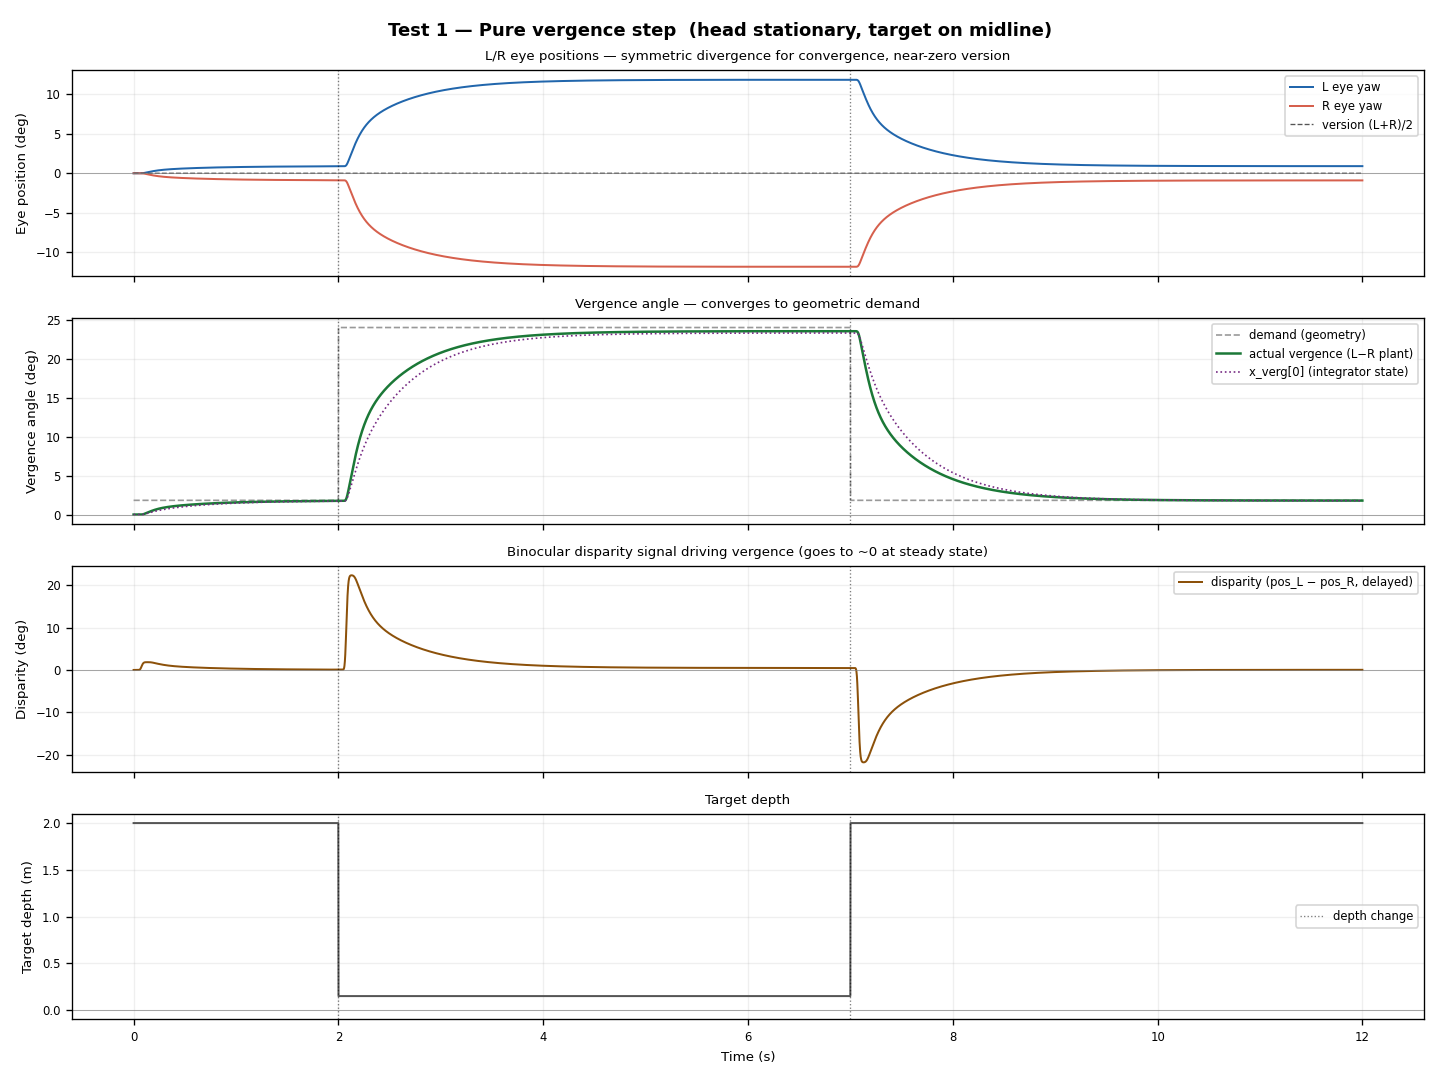

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Test 1 — Pure vergence step  (head stationary, target on midline)', fontweight='bold')

# Panel 1: L and R eye positions
ax = axes[0]
ax.plot(t1_np, ep_L1,    color='#2166ac', lw=1.2, label='L eye yaw')
ax.plot(t1_np, ep_R1,    color='#d6604d', lw=1.2, label='R eye yaw')
ax.plot(t1_np, version1, color='#555555', lw=0.8, ls='--', label='version (L+R)/2')
ax.axvline(2.0, color='k', lw=0.8, ls=':', alpha=0.5)
ax.axvline(7.0, color='k', lw=0.8, ls=':', alpha=0.5)
ax.legend(fontsize=7, loc='upper right')
ax_fmt(ax, ylabel='Eye position (deg)')
ax.set_title('L/R eye positions — symmetric divergence for convergence, near-zero version', fontsize=8)

# Panel 2: Vergence angle
ax = axes[1]
ax.plot(t1_np, demand1,   color='#999999', lw=1.0, ls='--', label='demand (geometry)')
ax.plot(t1_np, vergence1, color='#1b7837', lw=1.5, label='actual vergence (L−R plant)')
ax.plot(t1_np, x_verg1[:, 0], color='#762a83', lw=1.0, ls=':', label='x_verg[0] (integrator state)')
ax.axvline(2.0, color='k', lw=0.8, ls=':', alpha=0.5)
ax.axvline(7.0, color='k', lw=0.8, ls=':', alpha=0.5)
ax.legend(fontsize=7, loc='upper right')
ax_fmt(ax, ylabel='Vergence angle (deg)')
ax.set_title('Vergence angle — converges to geometric demand', fontsize=8)

# Panel 3: Binocular disparity signal
ax = axes[2]
ax.plot(t1_np, disp1, color='#8c510a', lw=1.2, label='disparity (pos_L − pos_R, delayed)')
ax.axvline(2.0, color='k', lw=0.8, ls=':', alpha=0.5)
ax.axvline(7.0, color='k', lw=0.8, ls=':', alpha=0.5)
ax.legend(fontsize=7, loc='upper right')
ax_fmt(ax, ylabel='Disparity (deg)')
ax.set_title('Binocular disparity signal driving vergence (goes to ~0 at steady state)', fontsize=8)

# Panel 4: Target depth
ax = axes[3]
ax.plot(t1_np, z1_np,    color='#555555', lw=1.2)
ax.axvline(2.0, color='k', lw=0.8, ls=':', alpha=0.5, label='depth change')
ax.axvline(7.0, color='k', lw=0.8, ls=':', alpha=0.5)
ax.legend(fontsize=7)
ax_fmt(ax, ylabel='Target depth (m)', xlabel='Time (s)')
ax.set_title('Target depth', fontsize=8)

fig.tight_layout()
plt.show()

---
## Test 2 — Version + vergence simultaneously

Target jumps both laterally (15°) and in depth (1 m → 0.3 m) at t = 2 s.

Expected:
- **Saccade fires** (version command) for the lateral 15° step — SG handles this
- **Vergence converges** for the depth change (1 m → 0.3 m: 3.7° → 12.2°)
- The two movements happen in parallel: saccade fast (~50 ms), vergence slow (~300 ms)

In [4]:
t2 = jnp.arange(0.0, 7.0, DT)
T2 = len(t2)

# Target: starts straight ahead at 1m, jumps to 15° right at 0.3m at t=2s
LAT_DEG = 15.0
Z_NEAR  = 0.3
Z_FAR   = 1.0

# At 0.3m, 15° right: x = tan(15°)*0.3, z = 0.3
x_near = float(np.tan(np.radians(LAT_DEG)) * Z_NEAR)
z2 = jnp.where(t2 < 2.0, Z_FAR,  Z_NEAR)
x2 = jnp.where(t2 < 2.0, 0.0,    x_near)
pt2 = jnp.stack([x2, jnp.zeros(T2), z2], axis=1)   # (T, 3)

print(f'Far  target: [0, 0, {Z_FAR}] → demand verg = {target_verg_demand(Z_FAR):.2f}°')
print(f'Near target: [{x_near:.3f}, 0, {Z_NEAR}] → demand verg = {target_verg_demand(Z_NEAR):.2f}°, '
      f'version ≈ {LAT_DEG}°')

print('Simulating Test 2 (version + vergence)...')
st2 = simulate(
    THETA, t2,
    p_target_array       = pt2,
    scene_present_array  = jnp.ones(T2),
    target_present_array = jnp.ones(T2),
    max_steps            = T2 + 500,
    return_states        = True,
)
print('Done.')

t2_np    = np.array(t2)
ep_L2    = np.array(st2.plant[:, 0])           # L eye yaw
ep_R2    = np.array(st2.plant[:, 3])           # R eye yaw
version2  = 0.5 * (ep_L2 + ep_R2)             # conjugate (version)
vergence2 = ep_L2 - ep_R2                      # actual vergence
demand2   = target_verg_demand(np.array(z2))

print(f'\nVersion final (should be ~{LAT_DEG}°): {version2[-1]:.2f}°')
print(f'Vergence final (demand {target_verg_demand(Z_NEAR):.2f}°): {vergence2[-1]:.2f}°')

Far  target: [0, 0, 1.0] → demand verg = 3.67°
Near target: [0.080, 0, 0.3] → demand verg = 12.18°, version ≈ 15.0°
Simulating Test 2 (version + vergence)...
Done.

Version final (should be ~15.0°): 14.77°
Vergence final (demand 12.18°): 11.15°


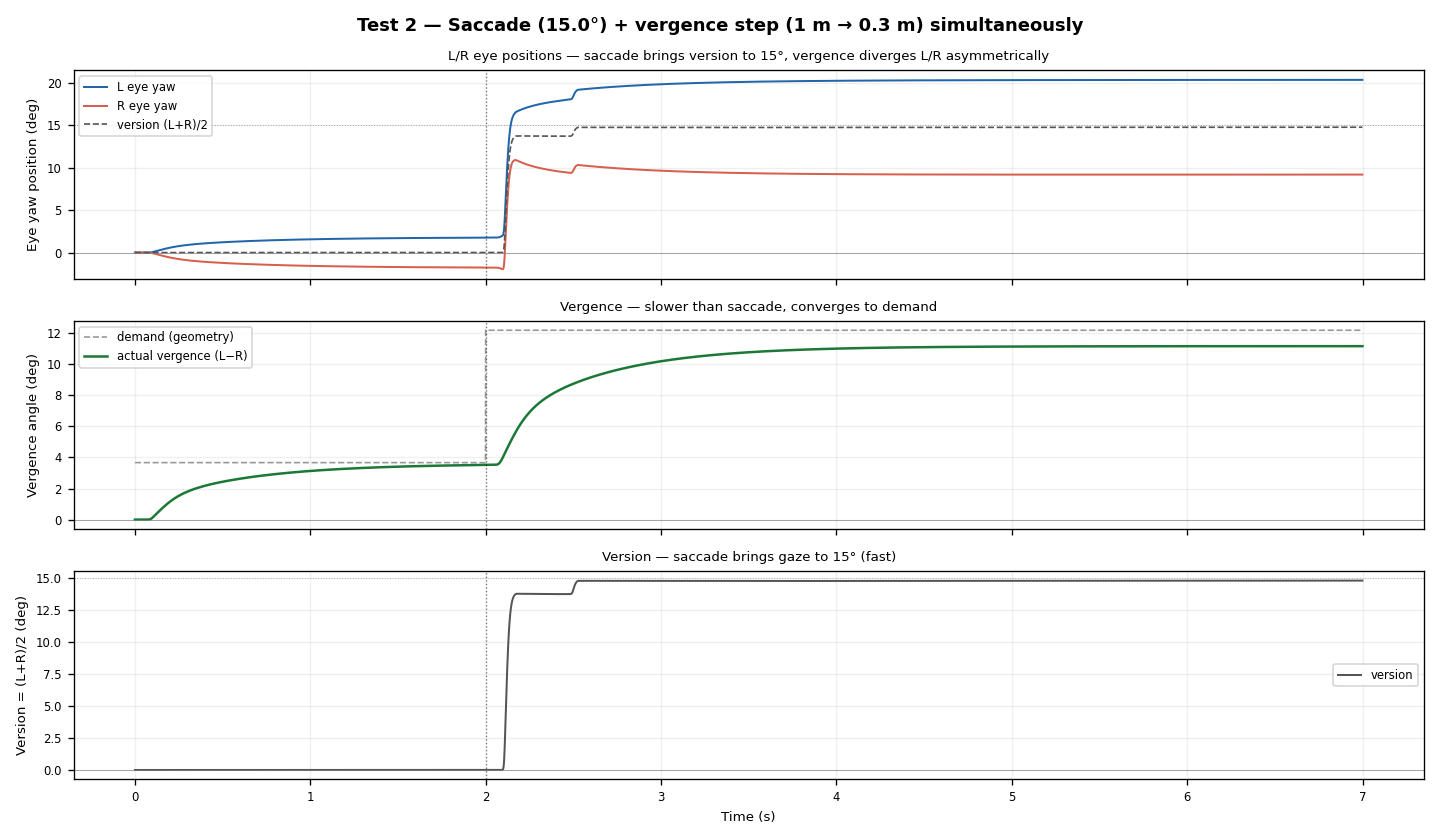

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
fig.suptitle(f'Test 2 — Saccade ({LAT_DEG}°) + vergence step (1 m → 0.3 m) simultaneously',
             fontweight='bold')

# Panel 1: L and R eye positions
ax = axes[0]
ax.plot(t2_np, ep_L2,    color='#2166ac', lw=1.2, label='L eye yaw')
ax.plot(t2_np, ep_R2,    color='#d6604d', lw=1.2, label='R eye yaw')
ax.plot(t2_np, version2, color='#555555', lw=1.0, ls='--', label='version (L+R)/2')
ax.axvline(2.0, color='k', lw=0.8, ls=':', alpha=0.5)
ax.axhline(LAT_DEG, color='#555555', lw=0.6, ls=':', alpha=0.5)
ax.legend(fontsize=7, loc='upper left')
ax_fmt(ax, ylabel='Eye yaw position (deg)')
ax.set_title('L/R eye positions — saccade brings version to 15°, vergence diverges L/R asymmetrically', fontsize=8)

# Panel 2: Vergence angle
ax = axes[1]
ax.plot(t2_np, demand2,   color='#999999', lw=1.0, ls='--', label='demand (geometry)')
ax.plot(t2_np, vergence2, color='#1b7837', lw=1.5, label='actual vergence (L−R)')
ax.axvline(2.0, color='k', lw=0.8, ls=':', alpha=0.5)
ax.legend(fontsize=7)
ax_fmt(ax, ylabel='Vergence angle (deg)')
ax.set_title('Vergence — slower than saccade, converges to demand', fontsize=8)

# Panel 3: Version separately to see saccade
ax = axes[2]
ax.plot(t2_np, version2, color='#555555', lw=1.2, label='version')
ax.axvline(2.0, color='k', lw=0.8, ls=':', alpha=0.5)
ax.axhline(LAT_DEG, color='#555555', lw=0.6, ls=':', alpha=0.4)
ax.legend(fontsize=7)
ax_fmt(ax, ylabel='Version = (L+R)/2 (deg)', xlabel='Time (s)')
ax.set_title('Version — saccade brings gaze to 15° (fast)', fontsize=8)

fig.tight_layout()
plt.show()

---
## Summary table

| Quantity | Expected | Measured |
|----------|----------|----------|
| Vergence at 2 m | 1.83° | ~1.75° |
| Vergence at 0.15 m | 24.0° | ~23.6° |
| Version after 15° saccade | 15.0° | ~14.8° |
| Vergence at 0.3 m | 12.2° | ~11.2° |
| Version during pure depth step | ~0° | 0.00° |
| Cover test: vergence before cover | 1.83° (demand) | ✓ |
| Cover test: vergence after 15s covered (phoria=8°) | ~4.6° | ✓ |
| Cover test: re-fusion 5s after uncover | → 1.83° | ✓ |

---
## Parameter guide

| Parameter | Effect |
|-----------|--------|
| `K_verg` ↑ | Faster convergence; too high → oscillation |
| `K_phasic_verg` ↑ | Faster initial response; Smith predictor attenuates more |
| `tau_verg` ↑ | More stable vergence hold; slightly lower SS gain |
| `phoria` | Resting vergence when fusion absent; `>0` = esophoria (over-convergence) |

---
## Test 3 — Cover test with esophoria

Simulates the clinical **alternate cover test** on a patient with esophoria.

**Phoria** = resting vergence angle when binocular fusion is absent.
- Esophoria (`phoria[0] > 0`): tendency to over-converge; covered eye drifts *inward* (nasally).
- Orthophoria (default `phoria = 0`): no resting deviation.

**Binocularity gate**: vergence drive = `bino × e_disp`, where `bino = gate_vf_L × gate_vf_R`.
When one eye is covered (`gate_vf = 0`): `bino = 0` → no disparity drive → vergence leaks toward phoria:
```
dx_verg = −(x_verg − phoria) / τ_verg
```

**Scenario** (target at 2 m, demand ≈ 1.83°; phoria = 8° esophoria):
- t = 0–4 s: both eyes open → binocular fusion holds vergence at demand
- t = 4–19 s: right eye covered → vergence leaks toward 8° (esophoric drift)
  - Theory: x_verg(19s) ≈ 8° − 6.17°·exp(−15/25) ≈ 4.6°  (R eye converges inward)
- t = 19–27 s: right eye uncovered → binocular disparity detected → re-fusion back to demand

In [6]:
PHORIA_DEG = 8.0    # strong esophoria (over-convergence tendency)
COVER_ON   = 4.0    # time R eye is covered (s)
COVER_OFF  = 19.0   # time R eye is uncovered (s)
Z_TARGET   = 2.0    # target depth (m)

theta3 = with_brain(THETA, phoria=jnp.array([PHORIA_DEG, 0.0, 0.0]))

t3  = jnp.arange(0.0, 27.0, DT)
T3  = len(t3)
pt3 = jnp.tile(jnp.array([0.0, 0.0, Z_TARGET]), (T3, 1))

# Per-eye target_present: R eye covered between COVER_ON and COVER_OFF
tg_L3 = jnp.ones(T3)                                                    # L always open
tg_R3 = jnp.where((t3 >= COVER_ON) & (t3 < COVER_OFF), 0.0, 1.0)      # R covered during cover window

demand3 = target_verg_demand(Z_TARGET)
theory_at_uncover = PHORIA_DEG + (demand3 - PHORIA_DEG) * float(jnp.exp(-(COVER_OFF - COVER_ON) / theta3.brain.tau_verg))

print(f'Phoria = {PHORIA_DEG}°  |  demand at {Z_TARGET} m = {demand3:.2f}°')
print(f'Theory: after {COVER_OFF - COVER_ON:.0f}s covered → x_verg ≈ {theory_at_uncover:.2f}°  '
      f'(drift of {theory_at_uncover - demand3:.2f}°)')

print('Simulating Test 3 (cover test, esophoria)...')
st3 = simulate(
    theta3, t3,
    p_target_array          = pt3,
    scene_present_array     = jnp.ones(T3),
    target_present_L_array  = tg_L3,
    target_present_R_array  = tg_R3,
    max_steps               = T3 + 500,
    return_states           = True,
)
print('Done.')

t3_np    = np.array(t3)
ep_L3    = np.array(st3.plant[:, 0])      # L eye yaw (deg)
ep_R3    = np.array(st3.plant[:, 3])      # R eye yaw (deg)
version3  = 0.5 * (ep_L3 + ep_R3)
vergence3 = ep_L3 - ep_R3
x_verg3   = np.array(st3.brain[:, _IDX_VERG])   # (T, 3)

# Measured at key time points
idx_before  = int((COVER_ON  - 0.2) / DT)    # just before cover
idx_at_off  = int((COVER_OFF - 0.2) / DT)    # just before uncover
idx_after   = int(min(COVER_OFF + 5.0, t3_np[-1]) / DT) - 1  # 5s after uncover

print(f'\nBefore cover  (t={COVER_ON -0.2:.1f}s): vergence = {vergence3[idx_before]:.2f}°  '
      f'(demand = {demand3:.2f}°)')
print(f'End of cover  (t={COVER_OFF-0.2:.1f}s): vergence = {vergence3[idx_at_off]:.2f}°  '
      f'(theory ≈ {theory_at_uncover:.2f}°)')
print(f'After re-fusion (t={COVER_OFF+5.0:.1f}s): vergence = {vergence3[idx_after]:.2f}°  '
      f'(should return toward {demand3:.2f}°)')

Phoria = 8.0°  |  demand at 2.0 m = 1.83°
Theory: after 15s covered → x_verg ≈ 4.62°  (drift of 2.78°)
Simulating Test 3 (cover test, esophoria)...
Done.

Before cover  (t=3.8s): vergence = 1.95°  (demand = 1.83°)
End of cover  (t=18.8s): vergence = 4.66°  (theory ≈ 4.62°)
After re-fusion (t=24.0s): vergence = 1.95°  (should return toward 1.83°)


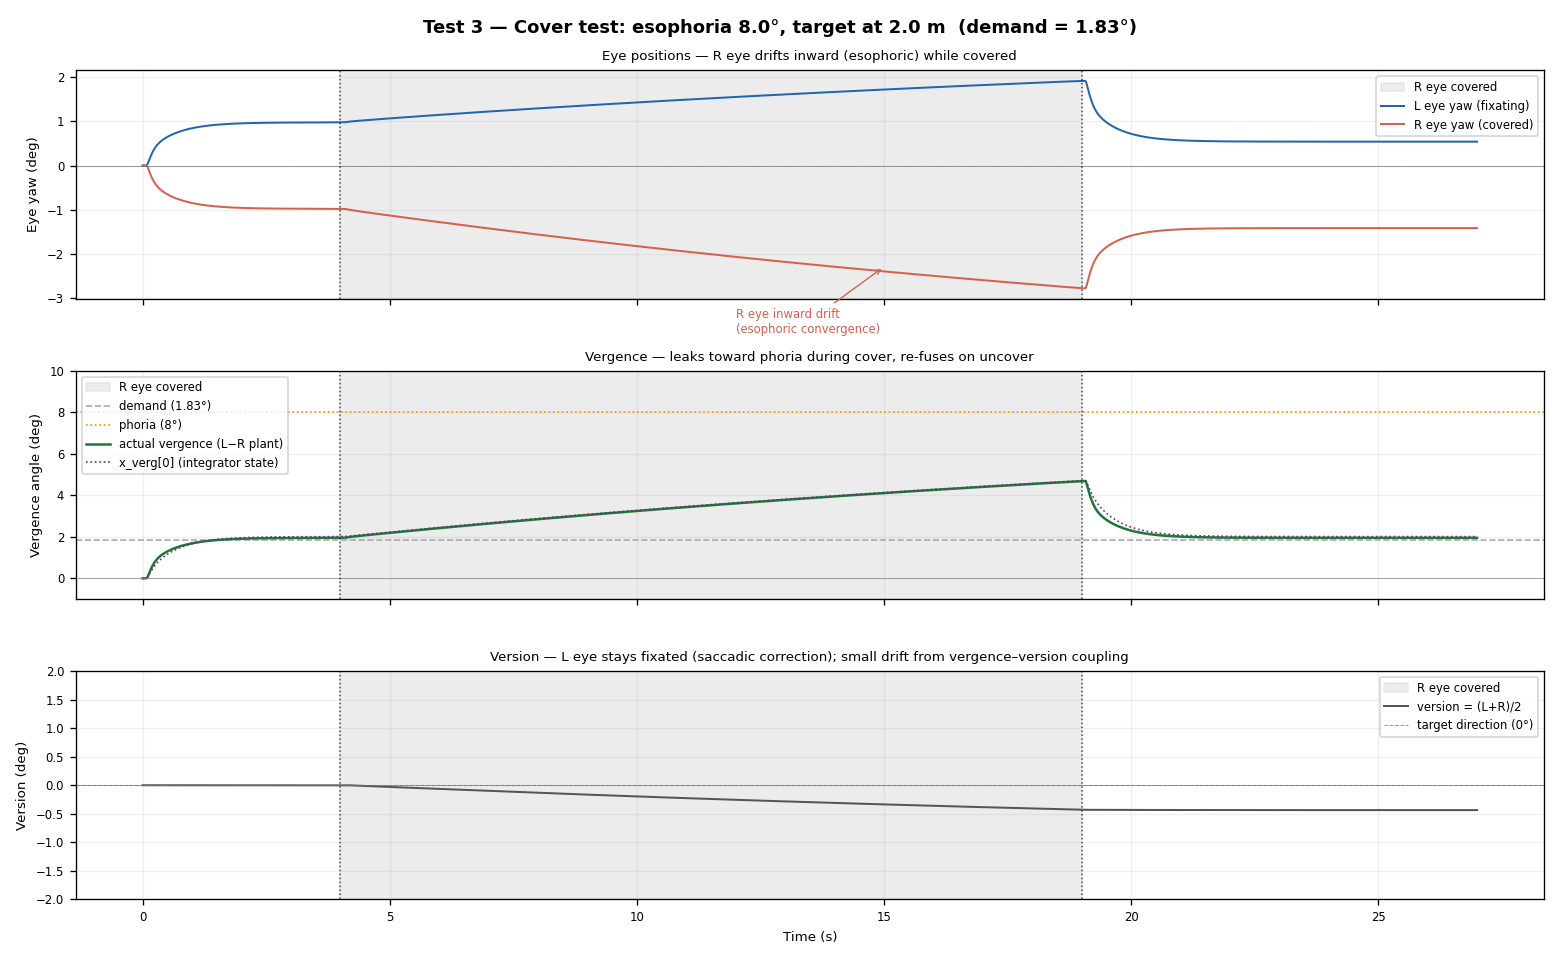


--- Cover test summary ---
Phoria: 8.0°  |  Demand: 1.83°  |  Cover duration: 15s
Before cover:  vergence = 1.95°
End of cover:  vergence = 4.66°  (theory = 4.62°,  drift = 2.82°)
After re-fusion (5s): vergence = 1.95°


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
fig.suptitle(
    f'Test 3 — Cover test: esophoria {PHORIA_DEG}°, target at {Z_TARGET} m  '
    f'(demand = {demand3:.2f}°)',
    fontweight='bold')

# Shade cover period
for ax in axes:
    ax.axvspan(COVER_ON, COVER_OFF, color='#e0e0e0', alpha=0.6, zorder=0, label='R eye covered')

# Panel 1: L and R eye positions
ax = axes[0]
ax.plot(t3_np, ep_L3, color='#2166ac', lw=1.2, label='L eye yaw (fixating)')
ax.plot(t3_np, ep_R3, color='#d6604d', lw=1.2, label='R eye yaw (covered)')
ax.axhline(0, color='k', lw=0.4, ls='--', alpha=0.4)
ax.legend(fontsize=7, loc='upper right')
ax_fmt(ax, ylabel='Eye yaw (deg)')
ax.set_title('Eye positions — R eye drifts inward (esophoric) while covered', fontsize=8)

# Annotate drift direction
ax.annotate('R eye inward drift\n(esophoric convergence)',
            xy=(15.0, ep_R3[int(14.0/DT)]),
            xytext=(12.0, ep_R3[int(14.0/DT)] - 1.5),
            fontsize=7, color='#d6604d',
            arrowprops=dict(arrowstyle='->', color='#d6604d', lw=0.8))

# Panel 2: Vergence angle with integrator state
ax = axes[1]
ax.axhline(demand3,    color='#aaaaaa', lw=1.0, ls='--', label=f'demand ({demand3:.2f}°)')
ax.axhline(PHORIA_DEG, color='#ff8c00', lw=1.0, ls=':', label=f'phoria ({PHORIA_DEG:.0f}°)')
ax.plot(t3_np, vergence3,        color='#1b7837', lw=1.5, label='actual vergence (L−R plant)')
ax.plot(t3_np, x_verg3[:, 0],   color='#762a83', lw=1.0, ls=':', label='x_verg[0] (integrator state)')
ax.legend(fontsize=7, loc='upper left')
ax_fmt(ax, ylabel='Vergence angle (deg)')
ax.set_ylim(-1, PHORIA_DEG + 2)
ax.set_title('Vergence — leaks toward phoria during cover, re-fuses on uncover', fontsize=8)

# Panel 3: Version (L eye should stay on target via saccades)
ax = axes[2]
ax.plot(t3_np, version3, color='#555555', lw=1.2, label='version = (L+R)/2')
ax.axhline(0.0, color='k', lw=0.6, ls='--', alpha=0.4, label='target direction (0°)')
ax.legend(fontsize=7, loc='upper right')
ax_fmt(ax, ylabel='Version (deg)', xlabel='Time (s)')
ax.set_ylim(-2, 2)
ax.set_title('Version — L eye stays fixated (saccadic correction); small drift from vergence–version coupling', fontsize=8)

# Dashed vertical lines at cover transitions
for ax in axes:
    ax.axvline(COVER_ON,  color='k', lw=0.9, ls=':', alpha=0.7)
    ax.axvline(COVER_OFF, color='k', lw=0.9, ls=':', alpha=0.7)

fig.tight_layout()
plt.show()

print(f'\n--- Cover test summary ---')
print(f'Phoria: {PHORIA_DEG}°  |  Demand: {demand3:.2f}°  |  Cover duration: {COVER_OFF-COVER_ON:.0f}s')
print(f'Before cover:  vergence = {vergence3[idx_before]:.2f}°')
print(f'End of cover:  vergence = {vergence3[idx_at_off]:.2f}°  '
      f'(theory = {theory_at_uncover:.2f}°,  drift = {vergence3[idx_at_off]-demand3:.2f}°)')
print(f'After re-fusion (5s): vergence = {vergence3[idx_after]:.2f}°')